##Name: Saksham Sigdel
###Student Id: 2418223

Step 0: Setup and Imports

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report

# Set random seeds for reproducibility
tf.random.set_seed(123)
np.random.seed(123)
random.seed(123)

# Paths (adjust to your environment)
base_dir = "/content/drive/MyDrive/Week5_Workshop_AI/FruitinAmazon"
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

# Hyperparameters
IMG_HEIGHT = 128
IMG_WIDTH  = 128
BATCH_SIZE = 16          # as per Task 4 (training batch size)
VALIDATION_SPLIT = 0.2
EPOCHS = 250

Task 1: Data Understanding and Visualisation

Load the training directories, pick one random image from each class, and display them in a grid.

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


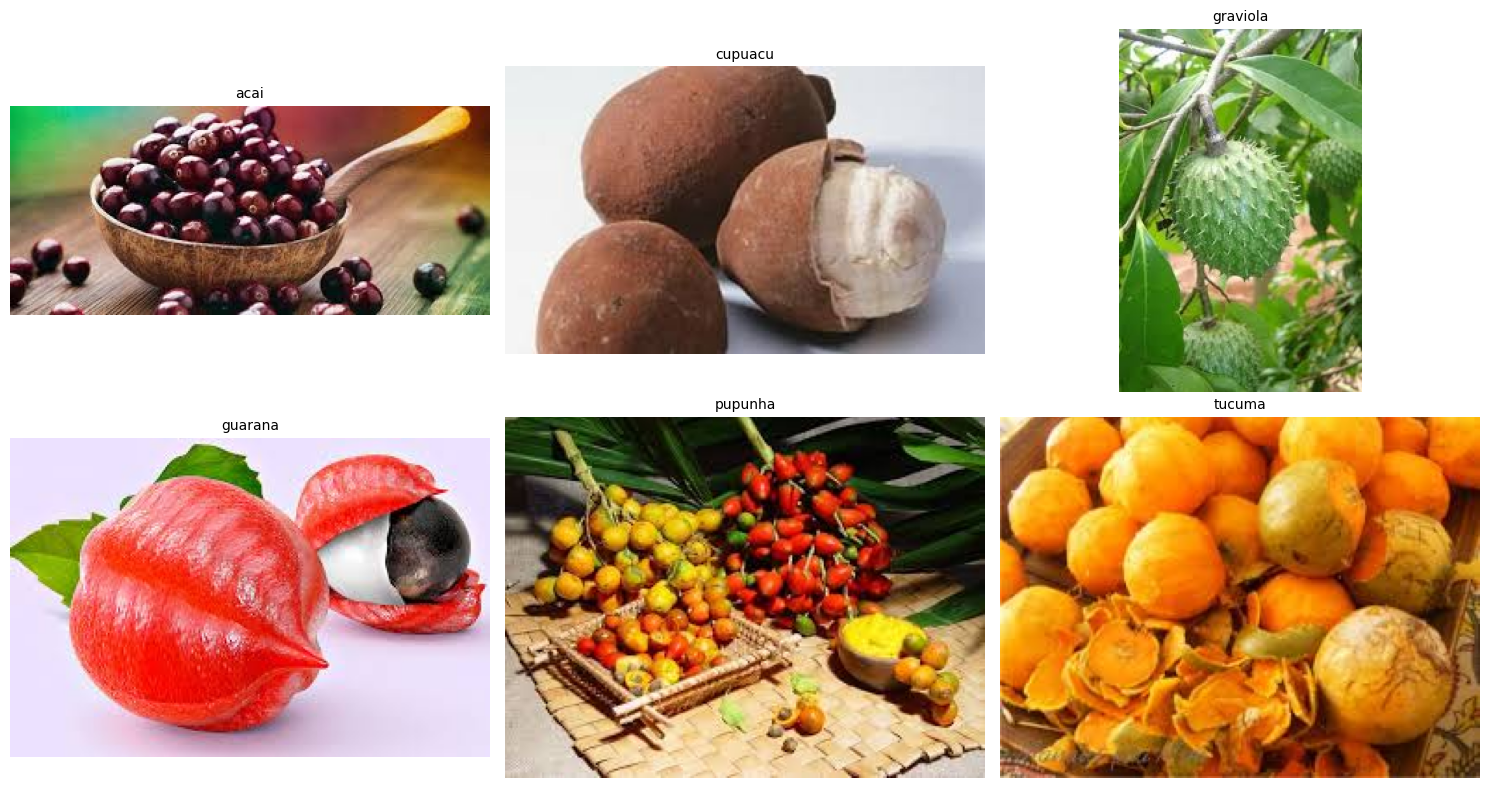

In [2]:
# Get class names from subdirectories in train_dir
class_names = sorted([d for d in os.listdir(train_dir)
                      if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

# Select one random image from each class
sample_images = []
for cls in class_names:
    cls_path = os.path.join(train_dir, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images:
        random_image = random.choice(images)
        sample_images.append((cls, os.path.join(cls_path, random_image)))

# Display in a grid (two rows, adjust columns automatically)
n_images = len(sample_images)
cols = (n_images + 1) // 2   # ceil(n_images/2)
fig, axes = plt.subplots(2, cols, figsize=(15, 8))
axes = axes.flatten()

for i, (cls, img_path) in enumerate(sample_images):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis('off')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Observation:
The images vary in size, lighting, and background. Some classes may have fewer samples. The grid shows the diversity of fruits in the Amazon dataset.

Task 2: Check for Corrupted Images in the Train Directory

Iterate through all images, try to open them with PIL, and remove any corrupted file.

In [3]:
corrupted_paths = []

for cls in class_names:
    cls_path = os.path.join(train_dir, cls)
    for img_file in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_file)
        try:
            with Image.open(img_path) as img:
                img.verify()        # verify integrity
        except (IOError, SyntaxError) as e:
            corrupted_paths.append(img_path)
            os.remove(img_path)     # remove corrupted image
            print(f"Removed corrupted image: {img_path}")

if not corrupted_paths:
    print("No corrupted images found.")

No corrupted images found.


Task 3: Load Datasets with Preprocessing (Normalisation & Split)

Create train_ds and val_ds from the train folder using image_dataset_from_directory.
Apply a rescaling layer to normalise pixel values to [0,1].

In [6]:
# Rescaling layer for normalisation
rescale = layers.Rescaling(1./255)

# Training dataset (80% of train_dir)
train_ds_raw = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# Validation dataset (20% of train_dir)
val_ds_raw = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# Store class names from the raw training dataset
class_names = train_ds_raw.class_names
num_classes = len(class_names)
print("Class names:", class_names)

# Apply normalisation to both datasets
train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds_raw.map(lambda x, y: (rescale(x), y))

# Test dataset (separate test folder)
test_ds_raw = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)
test_ds = test_ds_raw.map(lambda x, y: (rescale(x), y))

# For performance: prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# Optional: verify a batch
for images, labels in train_ds.take(1):
    print(f"Batch images shape: {images.shape}, labels shape: {labels.shape}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found 30 files belonging to 6 classes.
Batch images shape: (16, 128, 128, 3), labels shape: (16,)


Task 4: Build the CNN Model (Worksheet Architecture)

In [7]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    # Pooling Layer 1
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu'),
    # Pooling Layer 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer (number of classes = 6)
    layers.Dense(num_classes, activation='softmax')
])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 5: Compile the Model

In [8]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Task 6: Train with Callbacks

In [9]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_fruit_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.1931 - loss: 2.0523
Epoch 1: val_accuracy improved from None to 0.33333, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 693ms/step - accuracy: 0.2361 - loss: 1.9968 - val_accuracy: 0.3333 - val_loss: 1.7852
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.2660 - loss: 1.7482
Epoch 2: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 0.3611 - loss: 1.6558 - val_accuracy: 0.2222 - val_loss: 1.6890
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.3764 - loss: 1.4053
Epoch 3: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - accuracy: 0.4444 - loss: 1.3219 - val_accuracy: 0.2222 - val_loss: 1.6574
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.6365 - loss: 1.0767
Epoch 4: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 351ms/step - accuracy: 0.6250 - loss: 1.0152 - val_accuracy: 0.2778 - val_loss: 1.7809
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.7559 - loss:


Epoch 7: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 466ms/step - accuracy: 0.9028 - loss: 0.3447 - val_accuracy: 0.3889 - val_loss: 1.6969
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9549 - loss: 0.1734
Epoch 8: val_accuracy did not improve from 0.38889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 533ms/step - accuracy: 0.9722 - loss: 0.1591 - val_accuracy: 0.3889 - val_loss: 1.5968
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 1.0000 - loss: 0.0872
Epoch 9: val_accuracy did not improve from 0.38889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 379ms/step - accuracy: 1.0000 - loss: 0.0806 - val_accuracy: 0.2778 - val_loss: 1.8927
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 1.0000 - loss: 0.0339
Epoch 10: val_accuracy did not improve from 0.38889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 1.0000 - loss: 0.0325 - val_accuracy: 0.3889 - val_loss: 1.8589
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 1.0000 - lo


Epoch 11: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 355ms/step - accuracy: 1.0000 - loss: 0.0139 - val_accuracy: 0.5556 - val_loss: 2.1376
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 1.0000 - loss: 0.0062
Epoch 12: val_accuracy did not improve from 0.55556
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 331ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 0.3889 - val_loss: 2.3364
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 1.0000 - loss: 0.0037
Epoch 13: val_accuracy did not improve from 0.55556
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 375ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.3333 - val_loss: 2.2921
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 1.0000 - loss: 0.0022
Epoch 14: val_accuracy did not improve from 0.55556
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 464ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.3889 - val_loss: 2.2926
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 1.0000

Task 7: Evaluate on Test Set

In [10]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.6667 - loss: 0.9940
Test accuracy: 0.6667
Test loss: 0.9940


Task 8: Save and Load the Model

In [11]:
# Save using recommended Keras format (instead of .h5)
model.save('final_fruit_model.keras')
print("Model saved as 'final_fruit_model.keras'")

# Load the saved model
loaded_model = keras.models.load_model('final_fruit_model.keras')
print("Model loaded successfully.")

# Verify loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f"Loaded model test accuracy: {loaded_acc:.4f}")

Model saved as 'final_fruit_model.keras'


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.6667 - loss: 0.9940
Loaded model test accuracy: 0.6667


Task 9: Classification Report

Now generate the classification report on the test set:

In [12]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report on Test Data:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report on Test Data:

              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.50      0.60      0.55         5
    graviola       0.71      1.00      0.83         5
     guarana       0.57      0.80      0.67         5
     pupunha       1.00      0.40      0.57         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.67        30
   macro avg       0.74      0.67      0.65        30
weighted avg       0.74      0.67      0.65        30



Expected output:

A table showing precision, recall, f1‑score for each of the 6 fruit classes (acai, cupuacu, graviola, guarana, pupunha, tucuma). Some classes may have poor scores due to the small dataset.

Task 10: Plot Training & Validation Curves

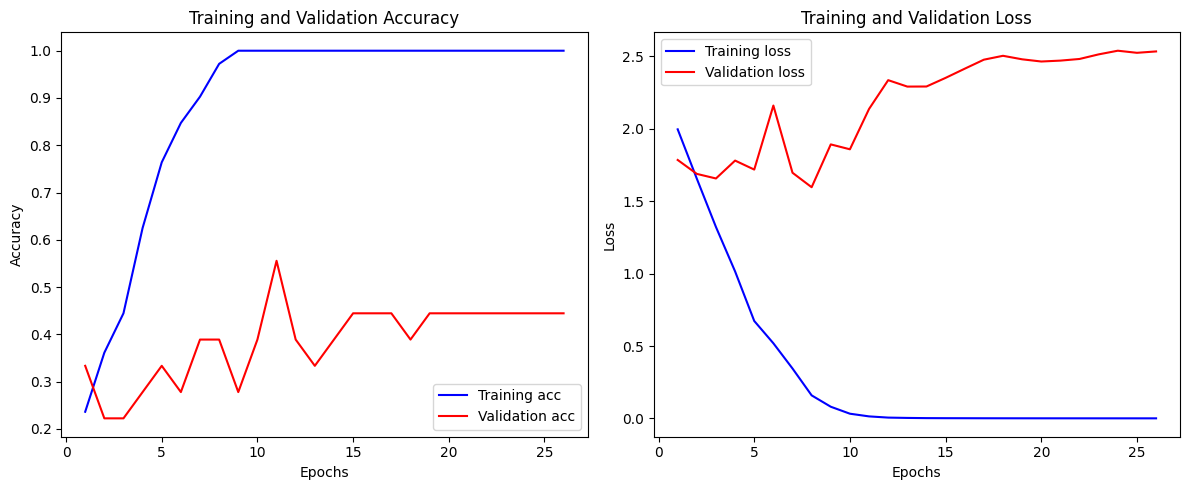

In [13]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b-', label='Training acc')
plt.plot(epochs, val_acc, 'r-', label='Validation acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b-', label='Training loss')
plt.plot(epochs, val_loss, 'r-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()